# Time Series Analysis — Forecasting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/02-unsupervised-learning/time-series-forecasting/notes.ipynb)

*Picks up exactly where [Time Series — Cleaning, Trend & Seasonality](../time-series/notes.ipynb) left off:
same dataset, cleaned the same way, now used to actually predict the future instead of just describing the
past.*


## 1. From understanding to predicting

The last notebook answered "what happened, and why?" — missing values, anomalies, trend, seasonality. This one
answers a different question: "what happens next?" That's forecasting, and it needs the same cleaned series,
rebuilt the same way (interpolate the gaps, clip the two mistakes).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

DATA_PATH = "../time-series/data/monthly-revenue.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["month"]).set_index("month").asfreq("MS")
df["revenue"] = df["revenue"].interpolate(method="linear")
lower, upper = df["revenue"].quantile([0.02, 0.98])
df["revenue_clean"] = df["revenue"].clip(lower=lower, upper=upper)

series = df["revenue_clean"]
print(f"{len(series)} months, {series.index.min().date()} to {series.index.max().date()}")

192 months, 2008-01-01 to 2023-12-01


## 2. Splitting the data — chronologically, not randomly

A normal `train_test_split()` picks rows at random. For a time series, that's wrong: a random split could put
March 2015 in training and January 2015 in testing, which means the model would effectively be trained on data
from *after* the point it's being asked to predict. That's information leaking backward from the future — the
model would look artificially good during testing, then fail for real once it's actually forecasting.

The fix: split by time. Everything before a cutoff date is training data, everything after is the test set —
exactly like the real situation of standing at a point in time and only being able to see the past.


In [2]:
train, test = series.iloc[:-12], series.iloc[-12:]
print(f"train: {len(train)} months, {train.index.min().date()} to {train.index.max().date()}")
print(f"test:  {len(test)} months,  {test.index.min().date()} to {test.index.max().date()}")

train: 180 months, 2008-01-01 to 2022-12-01
test:  12 months,  2023-01-01 to 2023-12-01


15 years to train on, the last 12 months held back to check every forecast against. The model below never sees
2023 while it's being fit — only afterward, to score it.


## 3. How do you measure if a forecast is good?

Three common metrics, all comparing the forecast $\hat{y}$ to the real value $y$ over the test period:

$$
\text{MAE} = \text{average of } |y - \hat{y}| \qquad
\text{RMSE} = \sqrt{\text{average of } (y - \hat{y})^2} \qquad
\text{MAPE} = \text{average of } \frac{|y - \hat{y}|}{y}
$$

- **MAE** — average error, in the same unit as the data (₹). Easy to read, but ₹3,000 off means something very
  different for a ₹10,000/month business than a ₹10,00,000/month one.
- **RMSE** — like MAE, but squares the errors first. A few large misses hurt the score more than many small ones.
- **MAPE** — turns the error into a *percentage* of the actual value, so it's comparable across completely
  different scales. A MAPE of 5% means "off by 5% on average," whether revenue is in thousands or in crores.

**The catch with MAPE**: if the actual value is ever exactly 0, it breaks — you'd be dividing by zero. That's not
a concern here, since monthly revenue for this business is never actually zero, but it matters for series that
can hit 0 (like daily units sold of a rarely-purchased item).


In [3]:
def mae(actual, forecast):
    return np.mean(np.abs(actual - forecast))

def rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

def mape(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

scorecard = {}

## 4. Baselines — before trying anything clever

Three deliberately simple forecasts. The point isn't that these are good — it's that any real method needs to
beat them to justify its own complexity.

- **Mean forecast**: predict the training average, for every future month.
- **Naive forecast**: predict last month's value, repeated forward.
- **Seasonal naive forecast**: predict whatever that same calendar month did last year (December 2023 = December
  2022's value). This is the first baseline that has any notion of seasonality at all.


In [4]:
mean_fc = pd.Series(train.mean(), index=test.index)
naive_fc = pd.Series(train.iloc[-1], index=test.index)
seasonal_naive_fc = pd.Series(train.iloc[-12:].values, index=test.index)

for name, fc in [("mean", mean_fc), ("naive", naive_fc), ("seasonal_naive", seasonal_naive_fc)]:
    scorecard[name] = (mae(test, fc), rmse(test, fc), mape(test, fc))

pd.DataFrame(scorecard, index=["MAE", "RMSE", "MAPE (%)"]).T.round(2)

,MAE,RMSE,MAPE (%)
mean,17483.03,17800.94,23.38
naive,3039.98,3463.79,4.13
seasonal_naive,2624.83,3284.31,3.54


The mean forecast is far worse than the other two (~23% MAPE) — expected, since it ignores 15 years of growth and
predicts a flat number stuck around the historical average. Naive and seasonal naive both do much better just by
using *recent* information instead of the full history. Seasonal naive edges out plain naive here, because it at
least accounts for the festive-season pattern that plain naive has no way to see.


## 5. Moving average forecast

The same moving average from the last notebook, but used differently: instead of describing the past, treat the
most recent average as the forecast for every future month.


In [5]:
window = 12
ma_last_value = train.rolling(window).mean().iloc[-1]
ma_fc = pd.Series(ma_last_value, index=test.index)
scorecard["moving_avg"] = (mae(test, ma_fc), rmse(test, ma_fc), mape(test, ma_fc))

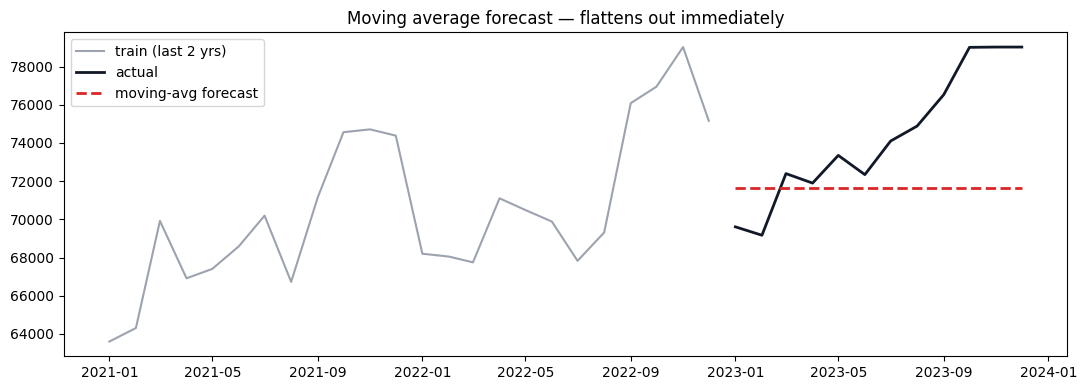

Moving average MAPE: 4.43%


In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train.index[-24:], train.iloc[-24:], color="#9ca3af", label="train (last 2 yrs)")
ax.plot(test.index, test, color="#111827", lw=2, label="actual")
ax.plot(test.index, ma_fc, color="#DC2626", lw=2, ls="--", label="moving-avg forecast")
ax.set_title("Moving average forecast — flattens out immediately")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Moving average MAPE: {scorecard['moving_avg'][2]:.2f}%")

The forecast is a single flat line — every future month gets the exact same number. That's the core weakness of
using a moving average to forecast rather than just to describe: since it only ever averages what already
happened, it has no way to keep climbing along with a genuine trend, and it comes out *worse* than even the
naive baseline here (4.43% vs 4.13%). Revenue keeps growing every year; a flat average falls further behind with
every step into the future.


## 6. Simple Exponential Smoothing (SES)

A smarter kind of averaging: instead of a hard cutoff window (the last `m` months, each weighted equally, then
nothing), give *every* past value some weight — just one that fades the further back it goes. A memory that
fades, instead of a memory that's cut off.

$$
\hat{y}_{t+1} = \alpha \, y_t + (1 - \alpha) \, \hat{y}_t
$$

`α` (alpha) controls how fast that memory fades, and it's always between 0 and 1:
- **Low α** — leans on the past, smoother, slower to react. Like someone who takes a long time to update their
  opinion.
- **High α** — leans almost entirely on the latest value, jumpier, quick to react. As `α → 1`, it becomes almost
  identical to the naive method.

A common starting rule of thumb: `α ≈ 1 / (2 × seasonality length)` — for monthly data with yearly seasonality,
that's `α ≈ 1/24 ≈ 0.04`, though the actual best value is normally fit from the data rather than guessed.


In [7]:
ses_model = SimpleExpSmoothing(train, initialization_method="estimated").fit()
ses_fc = ses_model.forecast(12)
scorecard["ses"] = (mae(test, ses_fc), rmse(test, ses_fc), mape(test, ses_fc))

print(f"Fitted alpha: {ses_model.params['smoothing_level']:.3f}")
print(f"SES MAPE: {scorecard['ses'][2]:.2f}%")

Fitted alpha: 0.225
SES MAPE: 3.79%


SES beats the plain moving average (3.79% vs 4.43%), because it keeps a bit of influence from every past month
rather than dropping anything older than 12 months entirely. But it still forecasts a **flat line** — SES only
ever tracks the current *level* of the series, with no idea that revenue has a trend or a seasonal rhythm. Both
of those need their own separate "memory."


## 7. Holt's method (Double Exponential Smoothing) — add a trend

Holt's method keeps **two** fading memories instead of one: `α` for the level (same as SES), and a second one,
`β` (beta), for the *trend* — how much the level itself is changing each month. Now the forecast isn't forced to
be flat; it can keep sloping upward (or downward) into the future.


In [8]:
holt_model = Holt(train, initialization_method="estimated").fit()
holt_fc = holt_model.forecast(12)
scorecard["holt"] = (mae(test, holt_fc), rmse(test, holt_fc), mape(test, holt_fc))

print(f"Fitted alpha: {holt_model.params['smoothing_level']:.3f}, beta: {holt_model.params['smoothing_trend']:.3f}")
print(f"Holt MAPE: {scorecard['holt'][2]:.2f}%")

Fitted alpha: 0.065, beta: 0.000
Holt MAPE: 3.21%


Holt's method drops the error further (3.21%), simply by letting the forecast keep climbing instead of going
flat. What it still can't do is repeat a *seasonal* shape — it has no memory of "October and November are always
higher."


## 8. Holt-Winters (Triple Exponential Smoothing) — add seasonality

One more fading memory, `γ` (gamma), for the seasonal pattern itself. Now there are three knobs, each answering
a different question:

| Knob | Controls | Reacts to |
|---|---|---|
| `α` (alpha) | level | recent changes in the overall value |
| `β` (beta) | trend | recent changes in the slope |
| `γ` (gamma) | seasonality | recent changes in the repeating calendar pattern |


In [9]:
hw_model = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=12, initialization_method="estimated"
).fit()
hw_fc = hw_model.forecast(12)
scorecard["holt_winters"] = (mae(test, hw_fc), rmse(test, hw_fc), mape(test, hw_fc))

print(f"Fitted alpha/beta/gamma: {hw_model.params['smoothing_level']:.3f} / "
      f"{hw_model.params['smoothing_trend']:.3f} / {hw_model.params['smoothing_seasonal']:.3f}")
print(f"Holt-Winters MAPE: {scorecard['holt_winters'][2]:.2f}%")

Fitted alpha/beta/gamma: 0.005 / 0.000 / 0.092
Holt-Winters MAPE: 2.01%


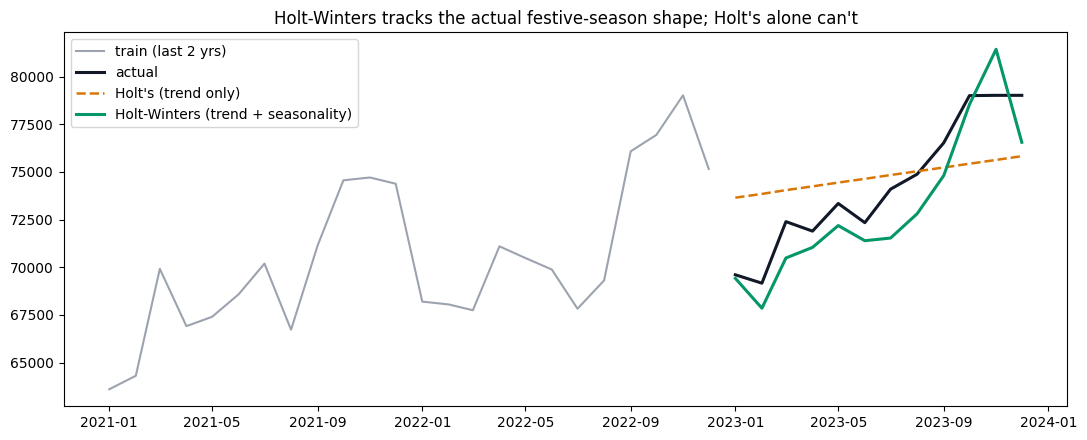

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(train.index[-24:], train.iloc[-24:], color="#9ca3af", label="train (last 2 yrs)")
ax.plot(test.index, test, color="#111827", lw=2.2, label="actual")
ax.plot(test.index, holt_fc, color="#D97706", lw=1.8, ls="--", label="Holt's (trend only)")
ax.plot(test.index, hw_fc, color="#059669", lw=2.2, label="Holt-Winters (trend + seasonality)")
ax.set_title("Holt-Winters tracks the actual festive-season shape; Holt's alone can't")
ax.legend()
plt.tight_layout()
plt.show()

Holt-Winters is the clear winner — it's the only method here whose forecast actually rises and dips in the same
shape as real revenue, instead of just sloping or sitting flat, because it's the only one carrying a memory of
level, trend, *and* the repeating seasonal rhythm at the same time.


## 9. Comparing every method


In [11]:
comparison = pd.DataFrame(scorecard, index=["MAE", "RMSE", "MAPE (%)"]).T.round(2)
comparison = comparison.sort_values("MAPE (%)")
comparison

,MAE,RMSE,MAPE (%)
holt_winters,1505.29,1690.91,2.01
holt,2372.29,2734.42,3.21
seasonal_naive,2624.83,3284.31,3.54
ses,2823.80,3352.11,3.79
naive,3039.98,3463.79,4.13
moving_avg,3379.84,4255.23,4.43
mean,17483.03,17800.94,23.38


Reading down this table by MAPE tells the whole story: ignoring recent information entirely (mean forecast) is
the worst by far. Using only the most recent value or two (naive, moving average) gets meaningfully better.
Fading memory that adapts over time (SES) edges past plain averaging. Adding a trend memory (Holt's) helps more.
Adding a seasonal memory on top of that (Holt-Winters) helps the most — each method fixes a specific blind spot
the previous one had, and the score improves every time one gets fixed.


## 10. Revisiting decomposition: additive or multiplicative?

The [previous notebook](../time-series/notes.ipynb) used `model="additive"` for decomposition without fully
explaining why. Here's the actual test: **does the size of the seasonal swing stay roughly constant, or does it
grow along with the trend?**

- **Additive** ($y_t = b_t + s_t + e_t$) — the seasonal swing stays about the same size in absolute terms,
  whether revenue is high or low.
- **Multiplicative** ($y_t = b_t \times s_t \times e_t$) — the seasonal swing grows *proportionally* as the trend
  grows, so it looks like a fixed percentage rather than a fixed amount.


In [12]:
early_std, early_mean = series.iloc[:60].std(), series.iloc[:60].mean()
late_std, late_mean = series.iloc[-60:].std(), series.iloc[-60:].mean()

print(f"First 5 years — average revenue ₹{early_mean:,.0f}, spread ₹{early_std:,.0f}")
print(f"Last 5 years  — average revenue ₹{late_mean:,.0f}, spread ₹{late_std:,.0f}")

First 5 years — average revenue ₹46,471, spread ₹6,785
Last 5 years  — average revenue ₹69,358, spread ₹6,166


Average revenue grew by roughly 50% (₹46,471 → ₹69,358), but the spread barely moved (₹6,785 → ₹6,166) — it
didn't grow along with the level, and if anything shrank slightly. That's the signature of **additive**
seasonality, confirming
`model="additive"` was the right call for this dataset. If the spread had grown roughly in step with the average
instead, that would have pointed to multiplicative seasonality, and the decomposition formula (and Holt-Winters'
`seasonal=` argument above) would need to switch to match.


## 11. Stationarity — what ARIMA-style models need

A different family of forecasting models (ARIMA and friends) doesn't work directly on the raw series — it needs
the series to be **stationary** first:

- No long-term upward or downward drift (no trend)
- No repeating calendar-based pattern (no seasonality)
- Roughly the same spread of ups and downs throughout, not growing wilder or calmer over time

Our revenue series is obviously not stationary — it has both a clear trend and clear seasonality. The
**Augmented Dickey-Fuller (ADF) test** checks this numerically instead of just by eye: it returns a p-value,
and the convention is `p < 0.05` → stationary, `p ≥ 0.05` → not stationary.


In [13]:
def report_adf(name, values):
    stat, pvalue = adfuller(values)[:2]
    verdict = "stationary" if pvalue < 0.05 else "NOT stationary"
    print(f"{name:<28} ADF stat = {stat:7.3f}   p-value = {pvalue:.4f}   → {verdict}")

report_adf("raw revenue", series.dropna())

raw revenue                  ADF stat =   0.074   p-value = 0.9642   → NOT stationary


/tmp/ipykernel_413/2080934337.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue = adfuller(values)[:2]


**Differencing** is the standard fix — instead of modeling the value itself, model how much it *changed* from
one step to the next. That one operation can knock out trend, seasonality, or both, depending on how it's
applied:

- **First differencing** (`diff(1)`) — each point minus the one right before it. Removes trend.
- **Seasonal differencing** (`diff(12)`) — each point minus the value 12 months earlier. Removes seasonality.
- **Both together** (`diff(1).diff(12)`) — removes trend and seasonality at once.


In [14]:
report_adf("after diff(1)", series.diff().dropna())
report_adf("after diff(12)", series.diff(12).dropna())
report_adf("after diff(1).diff(12)", series.diff().diff(12).dropna())

after diff(1)                ADF stat = -10.961   p-value = 0.0000   → stationary
after diff(12)               ADF stat =  -5.599   p-value = 0.0000   → stationary
after diff(1).diff(12)       ADF stat =  -5.408   p-value = 0.0000   → stationary


/tmp/ipykernel_413/2080934337.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue = adfuller(values)[:2]
/tmp/ipykernel_413/2080934337.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue = adfuller(values)[:2]
/tmp/ipykernel_413/2080934337.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag 

The raw series fails the test outright (p ≈ 0.96 — nowhere close to stationary, exactly as expected from a
series with obvious trend and seasonality). A single round of differencing is already enough to pass here
(p < 0.0001) — the trend by itself was the dominant source of non-stationarity in this data. This differencing
step is exactly what feeds into ARIMA-family models, which is where this series would go next.


## 12. Summary — revision cheat sheet

- **Chronological split**: for time series, training data must come entirely before test data — a random split
  leaks future information backward and makes results look better than they'd really be.
- **MAE / RMSE / MAPE**: MAPE is the one that's comparable across different scales, since it expresses error as
  a percentage. Breaks if the actual value is ever exactly 0.
- **Baselines** (mean, naive, seasonal naive) exist to set a floor — any real method needs to beat them.
- **Moving average / SES** forecast a flat line — good at smoothing the past, bad at projecting a trend forward.
- **Holt's method** adds a trend memory (`β`). **Holt-Winters** adds a seasonal memory too (`γ`) — on this
  dataset, it was the best of every method tried, because it's the only one tracking level, trend, *and*
  seasonality at once.
- **Additive vs. multiplicative**: check whether the seasonal swing's absolute size stays constant (additive) or
  grows with the trend (multiplicative).
- **Stationarity**: ARIMA-style models need it. Check with the ADF test (`p < 0.05` = stationary), fix it with
  differencing — first differencing removes trend, seasonal differencing removes seasonality.

**Coming next**: ARIMA/SARIMA, once I've read more about them — and UMAP, which is still on the list from the
previous notebook.
